## Fruchterman and Reingold algo testing

In [3]:
import importlib
import sys
from pathlib import Path

MAIN_PATH = Path.cwd().resolve()
if str(MAIN_PATH) not in sys.path:
	sys.path.insert(0, str(MAIN_PATH))

import gd_experiments as _g
importlib.reload(_g)

from gd_experiments import (
	METRIC_KEYS,
	appendLogRow,
	bestOfN,
	binaryPath,
	compileGd,
	logRowAsPairs,
	runGd,
	runRender,
	styleLogPairsTable,
)
from IPython.display import Image, display

print("binary:", binaryPath(MAIN_PATH))

binary: /Users/kirill/Code/Repos/promprog/GraphDrawing/build/graph_drawing


In [4]:
compileGd(MAIN_PATH)

-- Using the multi-header code from /Users/kirill/Code/Repos/promprog/GraphDrawing/build/_deps/nlohmann_json-src/include/
-- Configuring done (0.6s)
-- Generating done (0.0s)
-- Build files have been written to: /Users/kirill/Code/Repos/promprog/GraphDrawing/build
[  6%] Building CXX object CMakeFiles/graph_drawing.dir/src/app/artist.cpp.o
[ 13%] Building CXX object CMakeFiles/graph_drawing.dir/src/core/Embedding.cpp.o
[ 20%] Building CXX object CMakeFiles/graph_drawing.dir/src/core/Graph.cpp.o
[ 26%] Building CXX object CMakeFiles/graph_drawing.dir/src/core/InitialPlacement.cpp.o
[ 33%] Building CXX object CMakeFiles/graph_drawing.dir/src/io/Config.cpp.o
[ 40%] Building CXX object CMakeFiles/graph_drawing.dir/src/io/EmbeddingWriter.cpp.o
[ 46%] Building CXX object CMakeFiles/graph_drawing.dir/src/io/JsonGraphReader.cpp.o
[ 53%] Building CXX object CMakeFiles/graph_drawing.dir/src/layouts/FruchtermanAndReingold.cpp.o
[ 60%] Building CXX object CMakeFiles/graph_drawing.dir/src/layouts/L

Для начала базовый запуск с дефолтными параметрами

In [6]:
FLAGS = [
    "--graph",
	"graph1",
	"--algo",
	"far",
    "--initial-placement",
    "random",
    "--dim",
    "2",
    "--FS",
    "100, 100",
    "--dataset",
    "samples/dataset.json",
	"--output",
	"out/notebook/far/graph1.json",
]

ALGO_FLAGS = [
    "--C",
    "1.0",
    "--I",
    "100",
]


saved PNG to /Users/kirill/Code/Repos/promprog/GraphDrawing/out/notebook/far/graph1.png


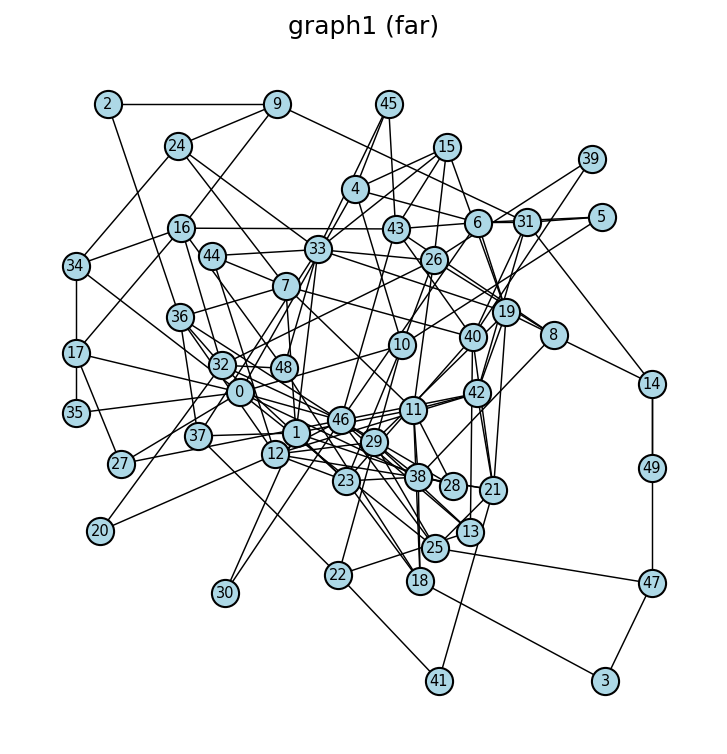

In [7]:
res = runGd(FLAGS, MAIN_PATH, algo_flags=ALGO_FLAGS)
png = runRender(MAIN_PATH, res["json_path"])
display(Image(filename=str(png)))

Вывод таблицы метрик:

In [8]:
image_score = 1.0

log_df = None
log_df = appendLogRow(
	log_df,
	res["metrics"],
	image_score=image_score,
	argv_repr=res["argv_repr"],
	algo_flags_repr=res["algo_flags_repr"],
	stdin_repr=res["stdin_repr"],
	json_path=res["json_path"],
	png_path=png,
)
display(styleLogPairsTable(logRowAsPairs(log_df)))

поле,значение
volume,10000.0
minVertexDist,5.156449
maxVertexDist,132.068089
avgVertexDist,49.156702
edgeCrossings,426
minAngle,0.0
maxAngle,3.140781
density,0.0
image_score,1.0
argv_repr,"--graph graph1 --algo far --initial-placement random --dim 2 --FS 100, 100 --dataset samples/dataset.json --output out/notebook/far/graph1.json"
